In [216]:
%load_ext autoreload
%autoreload 2

if __name__ == '__main__':
    import sys
    import os
    from pathlib import Path
    curr_file_path = Path(os.path.abspath(''))
    sys.path.append(str(curr_file_path.parent))

import numpy as np
import glob2 as glob
import matplotlib as mpl
import matplotlib.pyplot as plt
from aux_funcs import format_plot
import seaborn as sns

AVERAGING_SIZE = 20

# plt.rcParams['font.family'] = 'Helvetica Light'

color_high_reward = '#d95f02'
color_low_reward = '#1b9e77'
color_unrewarded = '#7570b3'
color_intersite = '#808080'
color_interpatch = '#b3b3b3'

odor_colors = [
    color_unrewarded,
    color_low_reward,
    color_high_reward,
]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


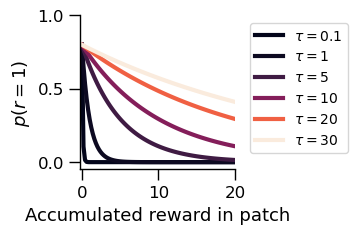

In [217]:
scale = 0.5
fig, axs = plt.subplots(1, 1, figsize=(4 * scale, 4 * scale))

cmap = sns.color_palette('rocket', as_cmap=True)

s = np.arange(0, 20)
x = np.linspace(0, 20, 100)
a = 0.8

for i, reward_param in enumerate([0.1, 1, 5, 10, 20, 30]):
    pr_disc = a * np.exp(-s/reward_param)
    pr_cont = a * np.exp(-x/reward_param)
    axs.plot(x, pr_cont, label=r'$\tau = $' + f'{reward_param}', c=cmap(reward_param / 30), lw=3)

axs.set_ylabel(r'$p(r=1)$', fontsize=13)
axs.set_xlabel('Accumulated reward in patch')
axs.set_xlim(-0.25, 20)
axs.set_ylim(-0.05, 1)
format_plot(axs)
fig.legend(bbox_to_anchor=(1.5, 0.875))



In [218]:
def load_data(data_path):
    file_names = sorted(glob.glob(data_path))
    data = []
    for file_name in file_names:
        data_for_file = np.load(file_name)
        data.append(data_for_file)
    data = np.stack(data)
    return data
    

In [250]:
def plot_reward_rates(
    data_dirs,
    colors=None,
    labels=None,
    bbox=(1.4, 0.5),
):
    scale = 0.6
    fig, axs = plt.subplots(1, 1, figsize=(6 * scale, 4 * scale))
    
    # Generate colors from a nice colormap if not provided
    if colors is None:
        cmap = plt.cm.tab10  # or try 'Set2', 'Dark2', 'viridis', etc.
        colors = [cmap(i % cmap.N) for i in range(len(data_dirs))]
    
    for i, data_dir in enumerate(data_dirs):
        reduced_data = load_data(data_dir + '/*')

        print(reduced_data.shape)
        
        # Plot shaded region for standard error
        axs.fill_between(
            np.arange(reduced_data.shape[0]),
            np.mean(reduced_data, axis=1) - np.std(reduced_data, axis=1) / np.sqrt(reduced_data.shape[1]),
            np.mean(reduced_data, axis=1) + np.std(reduced_data, axis=1) / np.sqrt(reduced_data.shape[1]),
            color=colors[i],
            alpha=0.2,
            zorder=1,
        )
        
        # Plot mean line (only add label if labels is provided)
        plot_kwargs = {
            'c': colors[i],
            'linewidth': 1,
            'zorder': 2,
        }
        if labels is not None:
            plot_kwargs['label'] = labels[i]
        
        axs.plot(
            np.arange(reduced_data.shape[0]),
            np.mean(reduced_data, axis=1),
            **plot_kwargs
        )

        print(np.mean(reduced_data[-50:, :]))
    
    # Adjust axes limits
    # axs.set_xlim(2000)
    # axs.set_ylim(0.05, 0.08)
    
    # Add labels and titles
    axs.set_ylabel('Reward rate', fontsize=12)
    axs.set_xlabel('Epochs', fontsize=12)
    # axs.set_xscale('log')
    
    # Customize tick parameters
    axs.tick_params(axis='both', direction='in', length=6, width=1.5, labelsize=10)
    
    # Thicken the axes lines
    axs.spines['top'].set_linewidth(1.5)
    axs.spines['right'].set_linewidth(1.5)
    axs.spines['bottom'].set_linewidth(1.5)
    axs.spines['left'].set_linewidth(1.5)
    
    # Add grid for better readability
    axs.grid(visible=True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    
    # Add legend only if labels were provided
    if labels is not None:
        fig.legend(bbox_to_anchor=bbox, fontsize=10)
    
    format_plot(axs)
    return axs

### Training networks to infer environment parameters and make decisions based on global reward rate
I trained split A2C networks and two variants to solve a version of the task where each $\tau$ is drawn from a uniform distribution. The variants included auxiliary losses including (1) the prediction of the different tau of the environment and (2) the prediction of different values by the actor, which differed in their value of gamma.

The $\tau$ prediction auxiliary loss seems to be effective in getting networks to consider the global reward rate, but the multi-value networks appear to be unstable. I haven't really done a hyper parameter sweep though.

(5000, 100)
0.074022055
(5000, 100)
0.024794329
(5000, 100)
0.07711018


<Axes: xlabel='Epochs', ylabel='Reward rate'>

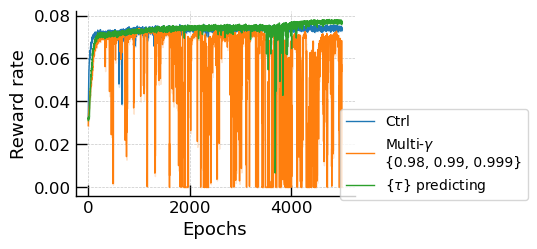

In [220]:
data_dirs = [
    '../../checkpoints/gru_exp_indep_pred_all_tau_0_gamma_0.999_seed_8002_seed_8002_2025-11-20_17:16:59.436020/_reward_rates',
    '../../checkpoints/gru_exp_indep_actor_gammas_gamma_0.999_seed_8002_seed_8002_2025-11-20_23:33:19.478419/_reward_rates',
    '../../checkpoints/gru_exp_indep_pred_all_tau_0.001_gamma_0.999_seed_8002_seed_8002_2025-11-21_04:44:14.907653/_reward_rates',
]
plot_reward_rates(
    data_dirs,
    labels=[
        'Ctrl',
        r'Multi-$\gamma$' + '\n{0.98, 0.99, 0.999}',
        r'$\{\tau\}$ predicting',
    ],
)

### Varying the weight of the $\tau$ prediction auxiliary loss
Auxiliary loss seems to hurt performance early on, but later results in better performance.

(5000, 100)
0.074022055
(5000, 100)
0.07711018
(5000, 100)
0.077123135
(1196, 100)
0.029486578


<Axes: xlabel='Epochs', ylabel='Reward rate'>

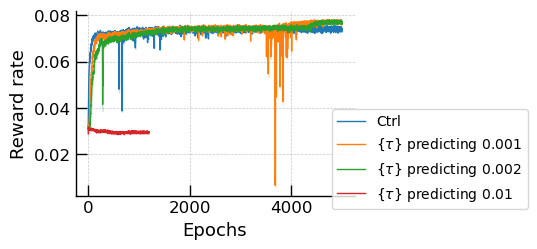

In [222]:
data_dirs = [
    '../../checkpoints/gru_exp_indep_pred_all_tau_0_gamma_0.999_seed_8002_seed_8002_2025-11-20_17:16:59.436020/_reward_rates',
    '../../checkpoints/gru_exp_indep_pred_all_tau_0.001_gamma_0.999_seed_8002_seed_8002_2025-11-21_04:44:14.907653/_reward_rates',
    '../../checkpoints/gru_exp_indep_pred_all_tau_0.002_gamma_0.999_seed_8002_seed_8002_2025-11-21_13:04:44.304115/_reward_rates',
    '../../checkpoints/gru_exp_indep_pred_all_tau_0.01_gamma_0.999_seed_8002_seed_8002_2025-11-21_11:54:14.910111/_reward_rates',
]
plot_reward_rates(
    data_dirs,
    labels=[
        'Ctrl',
        r'$\{\tau\}$ predicting 0.001',
        r'$\{\tau\}$ predicting 0.002',
        r'$\{\tau\}$ predicting 0.01',
    ],
)

### Attempting to train non-geometric value functions as auxiliary tasks

I trained an actor network with the auxiliary task of outputting additional value functions. These functions weighted future reward according to

$$
\tilde{V}^{(\gamma)}_t = \sum_{k=0}^\infty r_{t+k} (k+1) \gamma^k
$$

I chose 3 values of gamma, each to be trained independently, {0.95, 0.98, 0.99}. I extended the minibatch period to 400 time steps, and computed returns for only the first 200 time steps (to avoid bootstrapping).

Returns can be computed recursively by observing that

\begin{equation}
    \begin{split}
        \tilde{V}^{(\gamma)}_t &= \sum_{k=0}^\infty r_{t+k} (k+1) \gamma^k \\
        &= r_t + \sum_{k=1}^\infty r_{t+k} (k+1) \gamma^k \\
    \end{split}
\end{equation}

Relabeling with $k' = k - 1$,

\begin{equation}
    \begin{split}
        \tilde{V}^{(\gamma)}_t &= r_t + \sum_{k'=0}^\infty r_{t+k'+1} (k'+2) \gamma^{k'+1} \\
        &= r_t + \gamma \left( \sum_{k'=0}^\infty r_{t+k'+1} (k'+1) \gamma^{k'} + \sum_{k'=0}^\infty r_{t+k'+1} \gamma^{k'} \right) \\
        &= r_t + \gamma \left( \tilde{V}^{(\gamma)}_{t+1} + V^{(\gamma)}_{t+1} \right) \\
    \end{split}
\end{equation}

As far as I could tell, this only hindered performance. 

(5000, 100)
0.074022055
(5000, 50)
0.070942886
(5000, 50)
0.06392899
(362, 50)
0.030734485


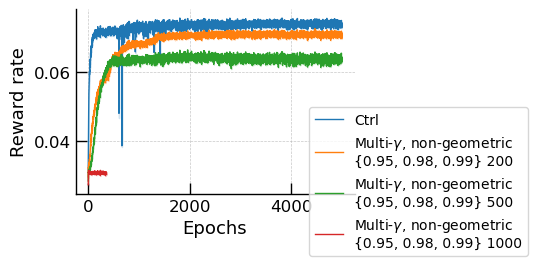

In [170]:
data_dirs = [
    '../../checkpoints/gru_exp_indep_pred_all_tau_0_gamma_0.999_seed_8002_seed_8002_2025-11-20_17:16:59.436020/_reward_rates',
    '../../checkpoints/gru_exp_indep_actor_non_geo_gammas_gamma_0.999_seed_8002_seed_8002_2025-11-27_16:55:45.543379/_reward_rates',
    '../../checkpoints/gru_exp_indep_actor_non_geo_500_gammas_gamma_0.999_seed_8002_seed_8002_2025-11-27_23:09:19.363608/_reward_rates',
    '../../checkpoints/gru_exp_indep_actor_non_geo_1000_gammas_gamma_0.999_seed_8002_seed_8002_2025-11-27_22:45:38.571050/_reward_rates',
]
axs = plot_reward_rates(
    data_dirs,
    labels=[
        'Ctrl',
        r'Multi-$\gamma$, non-geometric' + '\n{0.95, 0.98, 0.99} 200',
        r'Multi-$\gamma$, non-geometric' + '\n{0.95, 0.98, 0.99} 500',
        r'Multi-$\gamma$, non-geometric' + '\n{0.95, 0.98, 0.99} 1000',
    ],
)

(5000, 100)
0.074022055
(5000, 100)
0.074077725
(5000, 100)
0.070731424


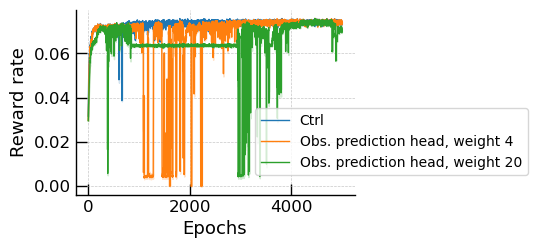

In [171]:
data_dirs = [
    '../../checkpoints/gru_exp_indep_pred_all_tau_0_gamma_0.999_seed_8002_seed_8002_2025-11-20_17:16:59.436020/_reward_rates',
    '../../checkpoints/gru_exp_indep_pred_obs_head_gamma_0.999_seed_8002_seed_8002_2025-11-28_00:58:42.202608/_reward_rates',
    '../../checkpoints/gru_exp_indep_pred_obs_head_20_gamma_0.999_seed_8002_seed_8002_2025-11-30_16:03:25.610696/_reward_rates',    
]
axs = plot_reward_rates(
    data_dirs,
    labels=[
        'Ctrl',
        'Obs. prediction head, weight 4',
        'Obs. prediction head, weight 20',
    ],
)

(5000, 100)
0.074022055
(5000, 100)
0.07293831
(5000, 100)
0.071370006


(0.0, 5000.0)

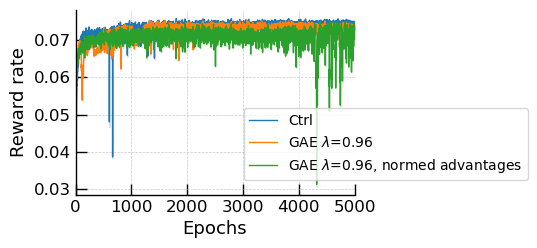

In [204]:
data_dirs = [
    '../../checkpoints/gru_exp_indep_pred_all_tau_0_gamma_0.999_seed_8002_seed_8002_2025-11-20_17:16:59.436020/_reward_rates',
    '../../checkpoints/gru_exp_indep_gae_lam_0.96_gamma_0.999_seed_8002_seed_8002_2025-12-01_10:49:50.839455/_reward_rates',
    '../../checkpoints/gru_exp_indep_norm_gae_lam_0.96_gamma_0.999_seed_8002_seed_8002_2025-12-01_10:56:47.657230/_reward_rates',

    
]
axs = plot_reward_rates(
    data_dirs,
    labels=[
        'Ctrl',
        r'GAE $\lambda$=0.96',
        r'GAE $\lambda$=0.96, normed advantages',
    ],
)
axs.set_xlim(0, 5000)

(5000, 100)
0.074022055
(319, 100)
0.067633316
(2344, 100)
0.07324943
(427, 100)
0.06989397


(0.0, 500.0)

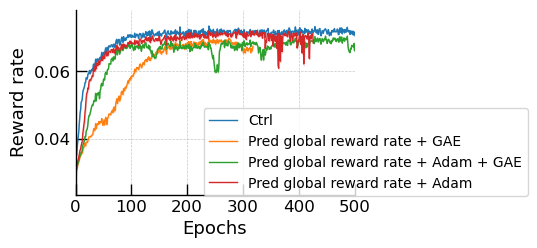

In [240]:
data_dirs = [
    '../../checkpoints/gru_exp_indep_pred_all_tau_0_gamma_0.999_seed_8002_seed_8002_2025-11-20_17:16:59.436020/_reward_rates',
    '../../checkpoints/gru_exp_indep_pred_global_reward_gamma_0.999_seed_8002_seed_8002_2025-12-04_17:56:52.953423/_reward_rates',
    '../../checkpoints/gru_exp_indep_pred_global_adam_reward_gamma_0.999_seed_8002_seed_8002_2025-12-04_18:24:13.153229/_reward_rates',
    '../../checkpoints/gru_exp_indep_pred_global_adam_reward_gamma_0.999_seed_8002_seed_8002_2025-12-04_21:40:16.324825/_reward_rates',

    
]
axs = plot_reward_rates(
    data_dirs,
    labels=[
        'Ctrl',
        r'Pred global reward rate + GAE',
        r'Pred global reward rate + Adam + GAE',
        r'Pred global reward rate + Adam',
    ],
)
axs.set_xlim(0, 500)

(5000, 100)
0.074022055
(5000, 100)
0.07413787
(5000, 100)
0.072457254
(4579, 100)
0.07389449
(4688, 100)
0.07382336


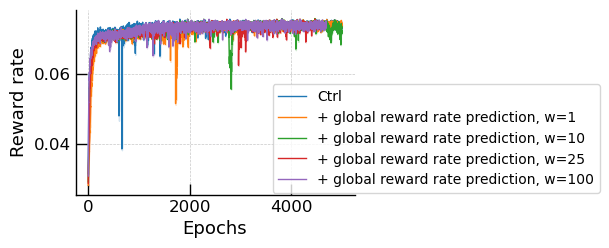

In [254]:
data_dirs = [
    '../../checkpoints/gru_exp_indep_pred_all_tau_0_gamma_0.999_seed_8002_seed_8002_2025-11-20_17:16:59.436020/_reward_rates',
    '../../checkpoints/gru_exp_indep_pred_global_reward_1_gamma_0.999_seed_8002_seed_8002_2025-12-04_22:22:17.986475/_reward_rates', # 1
    '../../checkpoints/gru_exp_indep_pred_global_reward_10_gamma_0.999_seed_8002_seed_8002_2025-12-04_22:20:39.779059/_reward_rates', # 10
    '../../checkpoints/gru_exp_indep_pred_global_reward_25_gamma_0.999_seed_8002_seed_8002_2025-12-05_03:59:24.204428/_reward_rates', # 25
    '../../checkpoints/gru_exp_indep_pred_global_reward_100_gamma_0.999_seed_8002_seed_8002_2025-12-05_03:54:11.447921/_reward_rates', # 100
]
axs = plot_reward_rates(
    data_dirs,
    labels=[
        'Ctrl',
        '+ global reward rate prediction, w=1',
        '+ global reward rate prediction, w=10',
        '+ global reward rate prediction, w=25',
        '+ global reward rate prediction, w=100',
    ],
    bbox=(1.6, 0.6)
)
# run sanity check on agent to see if it even predicts the global reward rate well

(5000, 100)
0.074022055
(5000, 100)
0.073933974
(5000, 100)
0.07396617


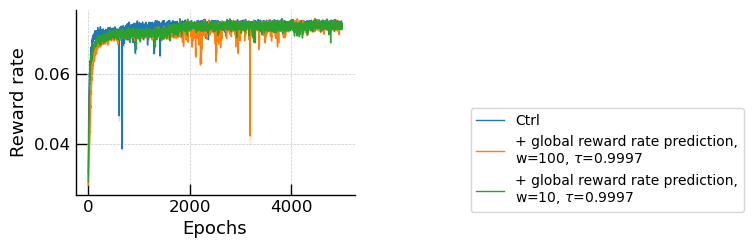

In [280]:
data_dirs = [
    '../../checkpoints/gru_exp_indep_pred_all_tau_0_gamma_0.999_seed_8002_seed_8002_2025-11-20_17:16:59.436020/_reward_rates',
    '../../checkpoints/gru_exp_indep_pred_global_reward_100_alpha_0.9907_seed_8002_seed_8002_2025-12-05_09:49:54.446481/_reward_rates',
    '../../checkpoints/gru_exp_indep_pred_global_reward_10_alpha_0.9997_seed_8002_seed_8002_2025-12-05_11:01:51.407821/_reward_rates',
]
axs = plot_reward_rates(
    data_dirs,
    labels=[
        'Ctrl',
        '+ global reward rate prediction,\nw=100, ' + r'$\tau$=0.9997',
        '+ global reward rate prediction,\nw=10, ' + r'$\tau$=0.9997',
    ],
    bbox=(2, 0.5)
)